In [1]:
"""
This document is about sampling and the different types dicsussed in Prof. Wu's lectures

What is Sampling?
    The process of drawing a subset of data points from a larger population

Data Sampling
    Selecting a subset of data from your dataset
Distribution Sampling
    Generating new data points that follow a given probability distribution

Why Sample?
    Estimating moments and parameters
    Simulating future data points (Price paths)
    Model Training (ML Models learn from samples of data)

Examples for Finance
    Bootstrapping (Resampling historical returns to estimate portfolio risk)
    Monte Carlo (Sampling price paths to price options or stress test portfolios)
    Walk Forward Validation (Sampling time windows correctly so you don't leak future data into model)


YT Link: https://www.youtube.com/watch?v=BWLr14MWtAA&list=PLdk2fd27CQzQCoOj0YfBd4ECr76EqEXz4&index=21

"""

"\nThis document is about sampling and the different types dicsussed in Prof. Wu's lectures\n\nWhat is Sampling?\n    The process of drawing a subset of data points from a larger population\n\nData Sampling\n    Selecting a subset of data from your dataset\nDistribution Sampling\n    Generating new data points that follow a given probability distribution\n\nWhy Sample?\n    Estimating moments and parameters\n    Simulating future data points (Price paths)\n    Model Training (ML Models learn from samples of data)\n\nExamples for Finance\n    Bootstrapping (Resampling historical returns to estimate portfolio risk)\n    Monte Carlo (Sampling price paths to price options or stress test portfolios)\n    Walk Forward Validation (Sampling time windows correctly so you don't leak future data into model)\n\n\nYT Link: https://www.youtube.com/watch?v=BWLr14MWtAA&list=PLdk2fd27CQzQCoOj0YfBd4ECr76EqEXz4&index=21\n\n"

In [ ]:
"""
What is a function inverse?

Lets say f(x) = 0.5x + 0.3
    We typically plug x in to f(x) and get a y
The inverse would be f^-1(y) = (y - 0.3) / 0.5
    This gets us an x from our y
"""

In [ ]:
"""
CDF of a prob dist.
    Returns the area under the curve up until the point given
    Area from left side until line at the point given
(Cumulative Distribution Function) - Cumulative because it includes until the point given
"""

In [ ]:
"""
Inversion Sampling Algorithm

1. You sample from uniform disribution between 0 and 1 as y
2. Pass y into CDF inverse to get x as the sample
3. Repeat this process

"""

In [23]:
import numpy as np
from numpy import random
import matplotlib.pyplot as plt
from scipy import stats


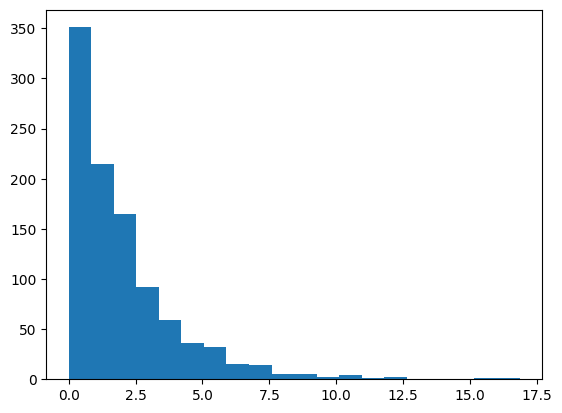

Sample mean: 1.9831743245844586, with expected mean: 2


In [3]:
# Inversion Sampling with Exp. Dist. (Mean = 2)
random_list = np.random.uniform(0, 1, 1000)
mean = 2

def inverse_exp(y, mean=2):
    # x = log(1-y) / -lambda : Lambda = 1/mean
    return np.log(1 - y) / -(1/mean)

samples = inverse_exp(random_list, mean=mean)

plt.hist(samples, bins=20)
plt.show()

sample_mean = np.mean(samples)
print(f"Sample mean: {sample_mean}, with expected mean: {mean}")

In [ ]:
"""
Rejection Sampling

Say we have p(x) = .3, .3, .4 but we don't know how to generate this
We can use q(x) = 1/3, 1/3, 1/3 and "Reject" at the rates in p(x)
"""

M: 1.2000000000000002


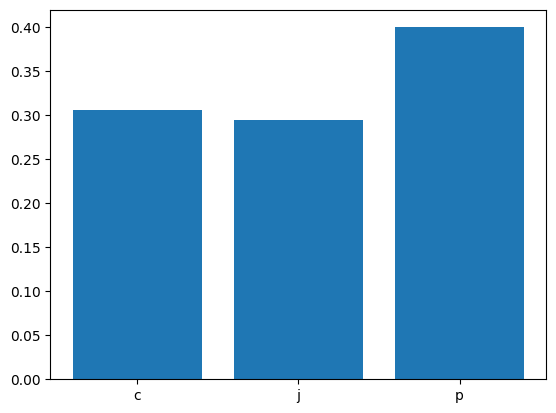

In [21]:
# Rejection Sampling to replicate p(x) = .3, .3, .4

# Target p(x) and proposal q(x) defined explicitly
p = {'c': 0.3, 'j': 0.3, 'p': 0.4}
q_x = 1/3  # uniform over 3 options

# M must satisfy M * q(x) >= p(x) for all x
# max(p(x) / q(x)) = 0.4 / (1/3) = 1.2, so M = 1.2 is the tightest valid choice
M = max(p[k] / q_x for k in p)
print(f"M: {M}")

q_sample = np.random.choice(['c', 'j', 'p'], size=10000)
p_sample = []
for x in q_sample:
    # Acceptance threshold: p(x) / (M * q(x)) — ratio of target to scaled proposal
    # Higher where p(x) is relatively large, lower where it's relatively small
    acceptance = p[x] / (M * q_x)
    if np.random.uniform(0, 1) < acceptance:
        p_sample.append(x)

values, counts = np.unique(p_sample, return_counts=True)
plt.bar(values, counts / len(p_sample))
plt.show()


M: 0.01


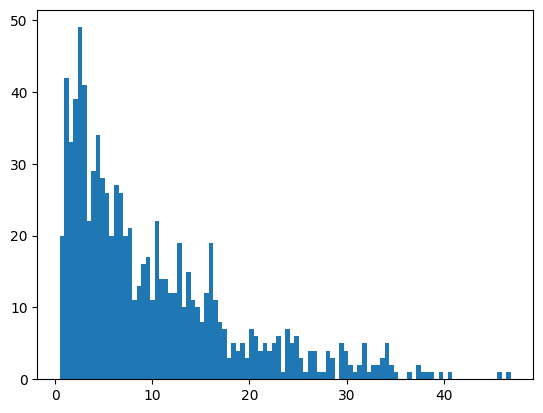

In [49]:
# Rejection Sampling with Chi^2 as p and Exp as q

def p_x(x, k=10):
    return scipy.stats.chi2.pdf(x, df=k)

def q_x(x, mean=10):
    return scipy.stats.expon.pdf(x, scale=mean)

prob_sample = np.random.uniform(0, 1, 4000)

M = max(p_x(x) / q_x(x) for x in prob_sample)
print(f"M: {M:.2f}")

exp_sample = np.random.exponential(scale=10, size=1000)

p_sample = []
for x in exp_sample:
    if np.random.uniform(0, 1) < p_x(x) / (M * q_x(x)):
        p_sample.append(x)

plt.hist(p_sample, bins=100)
plt.show()

In [ ]:
"""
Importance Sampling
    When you don't need to generate the sample
    You just need to calculate the integral

Still use p(x) and q(x), this time to estaimte E[X] (mean/expectation)

We will use chi^2 and exp again
"""

In [ ]:
# Importance sampling to find E[X] of chi^2 using exp
exp_sample = np.random.exponential(scale=10, size=1000)

weights = p_x(exp_sample) / q_x(exp_sample)

E_x = np.mean(exp_sample * weights)
print(f"E[X]: {E_x:.2f}")




E[X]: 10.01


In [ ]:
"""
We want to solve the folowing integral:
    By hand, using python integration, using sampling

int from 2 ->3 of x+1dx
"""

In [ ]:
# Estimating E[X] given f(x)
"""
By hand we get 1/2(x^2) + x plug in 3 - plug in 2

so you get 1/2(3^2) + 3 - 1/2(2^2) + 2
= 1/2(9) + 3 - 1/2(4) + 2
= 4.5 + 3 - 2 + 2 = 7.5 - 4 = 3.5

"""
print("By hand we get 3.5")

from scipy.integrate import quad
def p(x):
    return x + 1

print(f"With quad we get {quad(p, 2, 3)}")

samples = np.random.uniform(2, 3, 1000)
estimate = np.mean(samples + 1) * (3-2)
print(f"With sampling we get {estimate}")



By hand we get 3.5
With quad we get (3.5, 3.885780586188048e-14)
With sampling we get 3.507796630856254


In [61]:
# Solving more integrals
# Integral of 2x * e^(-2x) from 0 to 1

def int(x):
    return 2*x * np.exp(-2*x)

def p(x): # Finding p(x)
    return 2 * np.exp(-2*x)

def f(x):
    return x

print(f"With quad we get {quad(int, 0, 1)}")

samples = np.random.uniform(0, 1, 1000)
estimate = np.mean(int(samples))
print(f"With sampling we get {estimate}")




With quad we get (0.296997075145081, 3.297329910723967e-15)
With sampling we get 0.29590074398468347


In [ ]:
# Inversion, Rejection, and Importance Sampling

def f(x):
    return (x+1)

def p(x):
    return x**2

def int(x): # The integral we want to solve from 0 to 1
    return f(x) * p(x)

# Using Quad
print(f"With quad we get {quad(int, 0, 1)}")

# Using Inversion Sampling
samples = np.random.uniform(0, 1, 10000)

def normalize_p(x):
    return 3 * x**2


def inverse_p(y):
    return y ** (1/3)


inverse_samples = inverse_p(samples)

inversion_int = np.mean(f(inverse_samples))  * (1/3)
print(f"With sampling we get {inversion_int}")

# Using Rejection Sampling

samples = np.random.exponential(scale=1, size=10000)
rejection_samples = []

for sample in samples:
    if sample > 1:
        continue
    else:
        p_x = p(sample)
        random_number = np.random.uniform(0, 1)
        if random_number < p_x:
            rejection_samples.append(sample)

rejection_samples = np.array(rejection_samples)
rejection_int = np.mean(f(rejection_samples)) * (1/3)
print(f"With sampling we get {rejection_int}")

# Importance Sampling

samples = np.random.uniform(0, 1, 10000)
samples[samples > 1] = 0

weights = p(samples) 

importance_int = np.mean(f(samples) * weights)
print(f"With sampling we get {importance_int}")



With quad we get (0.5833333333333334, 6.47630097698008e-15)
With sampling we get 0.5819951464157589
With sampling we get 0.572542379467287
With sampling we get 0.5845337622424973
